In [6]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 윈도우 맑은 고딕 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 맥 애플고딕 설정
# plt.rcParams['font.family'] = 'AppleGothic'
# plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [9]:
file_path = r"C:\kdt_0900_hhj\data_analysis\resource\dataset"
file_name = r"hr_employee_attrition.csv"

file_path = os.path.join(file_path,file_name)

In [10]:
hr_df = pd.read_csv(file_path)
hr_df

,Attrition,Age,Gender,MaritalStatus,Education,Department,JobRole,BusinessTravel,OverTime,DistanceFromHome,MonthlyIncome,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,YearsAtCompany,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,PerformanceRating,YearsSinceLastPromotion
0,Yes,41,Female,Single,2,Sales,Sales Executive,Travel_Rarely,Yes,1,5993,11,0,8,6,2,4,1,3,0
1,No,49,Male,Married,1,Research & Development,Research Scientist,Travel_Frequently,No,8,5130,23,1,10,10,3,2,3,4,1
2,Yes,37,Male,Single,2,Research & Development,Laboratory Technician,Travel_Rarely,Yes,2,2090,15,0,7,0,4,3,3,3,0
3,No,33,Female,Married,4,Research & Development,Research Scientist,Travel_Frequently,Yes,3,2909,11,0,8,8,4,3,3,3,3
4,No,27,Male,Married,1,Research & Development,Laboratory Technician,Travel_Rarely,No,2,3468,12,1,6,2,1,2,3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,No,36,Male,Married,2,Research & Development,Laboratory Technician,Travel_Frequently,No,23,2571,17,1,17,5,3,4,3,3,0
1466,No,39,Male,Married,1,Research & Development,Healthcare Representative,Travel_Rarely,No,6,9991,15,1,9,7,4,1,3,3,1
1467,No,27,Male,Married,3,Research & Development,Manufacturing Director,Travel_Rarely,Yes,4,6142,20,1,6,6,2,2,3,4,0
1468,No,49,Male,Married,3,Sales,Sales Executive,Travel_Frequently,No,2,5390,14,0,17,9,4,2,2,3,0


In [ ]:
# 1. 야근(OverTime)을 하는 직원과 하지 않는 직원의 이직(Attrition) 비율은 얼마나 차이가 나는지 그래프로 나타내고 분석 결과를 서술하세요.
# - 집계 및 시각화: OverTime별 Attrition 비율(백분율, %)을 계산하고, 수치 차이가 대비되는 누적/그룹 그래프를 생성하세요.

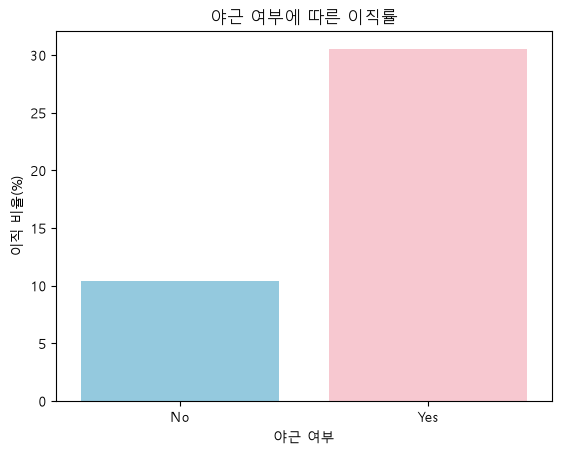

In [189]:
overtime_attrition = hr_df.groupby("OverTime")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100).reset_index().round(2)
overtime_attrition

sns.barplot(
    data=overtime_attrition,
    x="OverTime",
    y="Attrition",
    hue="OverTime",
    palette=(["skyblue","pink"])
)
plt.title("야근 여부에 따른 이직률")
plt.xlabel("야근 여부")
plt.ylabel("이직 비율(%)")
plt.show()

"""
    야근을 한 직원의 이직률이 야근을 하지 않은 직원보다 약 20% 높게 나타났다.
    야근 여부가 직원의 이직률에 영향을 주지 않았을까?
"""
None

In [ ]:
# 2. 이직한 직원(Yes)과 잔류한 직원(No)의 월소득(MonthlyIncome) 평균 및 분포에는 어떤 차이가 있는지 결과를 분석하고 그래프로 나타내고 서술하세요,
# - 이직 집단(Yes)과 잔류 집단(No)의 평균 월소득을 각각 산출하고, 소득의 분포와 이상치를 한눈에 파악할 수 있는 그래프를 생성하세요.

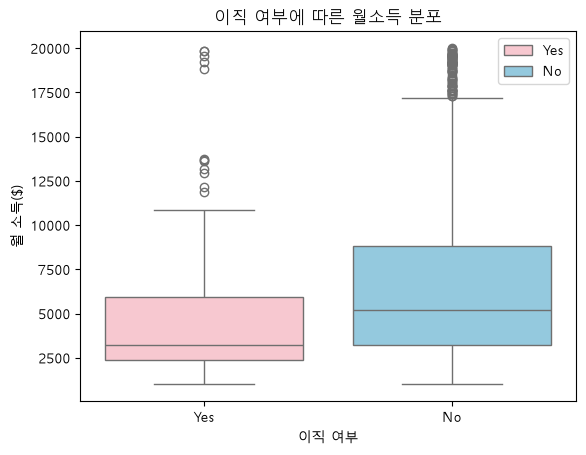

In [143]:
income_state = hr_df.groupby("Attrition")["MonthlyIncome"].agg(["count","mean","median","max","min","std"]).round(2)
income_state

sns.boxplot(
    data=hr_df,
    x="Attrition",
    y="MonthlyIncome",
    hue="Attrition",
    palette=(["pink","skyblue"])
)
plt.title("이직 여부에 따른 월소득 분포")
plt.xlabel("이직 여부")
plt.ylabel("월 소득($)")
plt.legend(["Yes","No"])
plt.show()

"""
    이직을 안 한 사람이 이직을 한 사람보다 월소득 평균이 더 높다. 월 소득은 이직률에 영향을 주는 것으로 예상할 수 있다.
"""
None

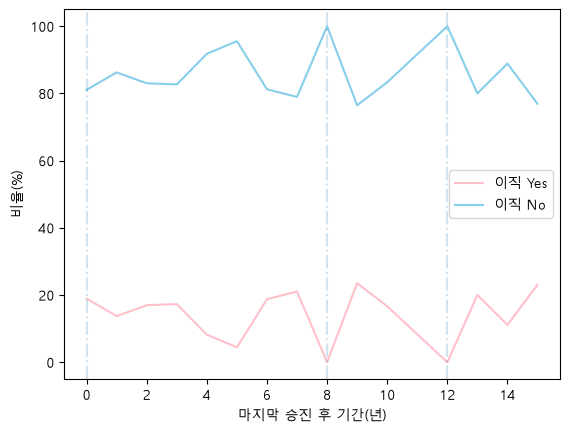

In [190]:
# 3. 마지막 승진 후 기간(YearsSinceLastPromotion)이 길어질수록 이직률이 높아진다는 가설이 맞는지 결과를 분석하고 그래프로 나타내고 서술하세요,
# - 마지막 승진 후 기간별 이직률(%)을 집계하고, 변화 흐름을 파악하기 적합한 그래프를 생성하세요.


promo_df = hr_df.groupby("YearsSinceLastPromotion")["Attrition"].agg(
    YesRate = lambda x: (x == "Yes").mean() * 100,
    NoRate = lambda x: (x == "No").mean() * 100
).reset_index().round(2)
promo_df

plt.plot(promo_df["YearsSinceLastPromotion"], promo_df["YesRate"], label="이직 Yes", color="pink")
plt.plot(promo_df["YearsSinceLastPromotion"], promo_df["NoRate"], label="이직 No", color="skyblue")
plt.xlabel("마지막 승진 후 기간(년)")
plt.ylabel("비율(%)")
plt.axvline(0, alpha=0.2, linestyle="-.")
plt.axvline(8, alpha=0.2, linestyle="-.")
plt.axvline(12, alpha=0.2, linestyle="-.")
plt.legend()
plt.show()


"""
    승진 직후 이직률이 20% 정도로 높게 나타나지만, 마지막 승진후 8년,12년이 지난 시점에는 이직률이 떨어지는 모습이 보인다. 
    그리고 그 다음 년도수에는 다시 이직률이 올라가는 불규칙한 그래프가 나타난다.
    마지막 승진 후 기간이 길어질수록 이직률이 높아진다고 보기 어렵다.
"""
None

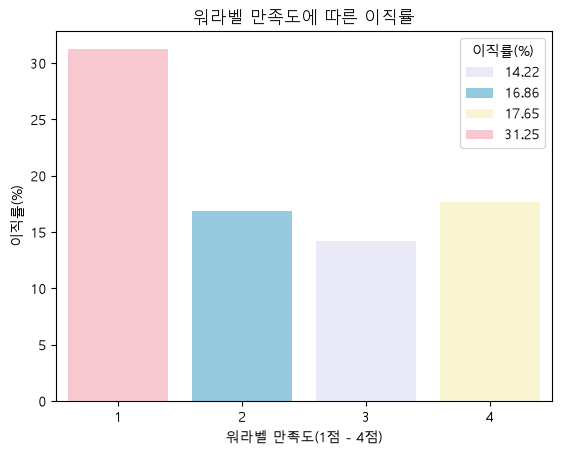

In [194]:
# 4. 워라밸 만족도(WorkLifeBalance: 1~4점) 점수별 이직률을 구하고, 워라밸이 낮을 때(1점)의 이직 위험도를 분석하고 그래프로 나타내고 서술하세요,
# - WorkLifeBalance 척도(1점: Bad ~ 4점: Best)별 이직률(%)을 구하고, 그룹 간 크기 비교에 적합한 그래프를 생성하세요.

wlb_df = hr_df.groupby("WorkLifeBalance")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100).reset_index().round(2)
wlb_df

sns.barplot(
    data=wlb_df,
    x="WorkLifeBalance",
    y="Attrition",
    hue="Attrition",
    palette=(["lavender","skyblue","lemonchiffon","pink"])
)
plt.title("워라벨 만족도에 따른 이직률")
plt.xlabel("워라벨 만족도(1점 - 4점)")
plt.ylabel("이직률(%)")
plt.legend(title="이직률(%)")
plt.show()

"""
    워라벨 만족도가 낮은 직원(1점)이 이직률이 높게 나타나지만, 만족도가 가장 높은 직원(4점)의 이직률이 두번째로 높게 나타났다.
    워라벨 만족도가 낮을수록 이직 가능성이 높다는 가설은 부분적으로는 맞지만 확언할 수 없음!
"""
None